# Clustering analysis

In [1]:
import joblib
import os
import time

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

from anomaly.utils import get_sdss_spec_img
from anomaly.constants import SDSS_NEBULAR_LINES_RATIOS_NAMES
from astroExplain.spectra.astronomy import BPT
from astroExplain.spectra import clustering
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Data igestion

In [2]:
def load_xai(run_id: str, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_arr = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")
    weights = np.load(f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r")
    return anomalies_arr, specobjids_arr, weights

In [3]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "unique_norm_weights": None,
        "norm_unique_norm_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["unique_norm_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["norm_weights"], n_segments=n_segments
    )

    data_dict["norm_unique_norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_norm_weights"]
    )

    return data_dict

## Top ranked explanations

In [4]:
def plot_top_ranked_explanations(
    metadata_df,
    spectra,
    norm_weights,
    wave,
    kmeans_model_dir,
    cluster_id,
    download_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
    skip_ranks_list=[-1],
):

    lw = 0.75

    n_anomalies_in_cluster = metadata_df.shape[0]
    print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

    for anomaly_rank in range(0, n_anomalies_in_cluster):

        if anomaly_rank == n_top_ranked:
            break
        if anomaly_rank + 1 in skip_ranks_list:
            print(f"Skipping rank {anomaly_rank + 1}.", end="\n")
            continue

        print(f"Explanation for anomaly rank {anomaly_rank + 1}", end="\r")

        specobjid = metadata_df.index[anomaly_rank]

        if download_images is True:
            os.makedirs(f"{kmeans_model_dir}/cluster_{cluster_id}", exist_ok=True)

            # check if the image already exists
            image_path = (
                f"{kmeans_model_dir}/cluster_{cluster_id}/image_{specobjid}.jpeg"
            )

            if not os.path.exists(image_path):

                ra, dec = metadata_df[["ra", "dec"]].loc[specobjid].values

                get_sdss_spec_img(
                    specobjid,
                    ra,
                    dec,
                    save_to=f"{kmeans_model_dir}/cluster_{cluster_id}",
                )

        spec = spectra[anomaly_rank]

        norm_weights_spec = norm_weights[anomaly_rank]
        if max_norm_weights is True:
            norm_weights_spec /= np.max(norm_weights_spec)

        fig, axs = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(20, 7),
            sharex=True,
            sharey=False,
        )
        # set minor ticks on
        for ax in axs.flatten():
            ax.minorticks_on()
        axs[0].plot(wave, spec, color="black", linewidth=lw)
        # weights
        axs[1].plot(
            wave, norm_weights_spec, color="black",
            label=f"Cluster {cluster_id}", linewidth=lw
        )

        axs[1].set_xlabel(r"$\lambda$ [nm]")
        axs[0].set_ylabel("Normalized flux")
        axs[1].set_ylabel("Explanation weights")
        axs[0].set_title(
            f"Rank: {anomaly_rank + 1:02d} - Cluster: {cluster_id}\n"
            f"Specobjid: {specobjid}"
        )

        axs[1].set_ylim(0, 0.4)
        y_ticks = np.arange(0, 0.41, 0.1)
        axs[1].set_yticks(y_ticks)

        if download_images is True:
            image_name = f"image_{specobjid}.jpeg"
        # Load the image
            img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")

            # Create inset in top-right corner of axs[0]
            width_height_image = 1
            axins = inset_axes(
                axs[0],
                width=width_height_image,
                height=width_height_image,
                bbox_to_anchor=(1.01, 1.02),
                bbox_transform=axs[0].transAxes,
                loc="upper right",
            )

            # Show image in the inset
            axins.imshow(img)
            axins.axis("off")  # Hide axis around the image
        explanation_name = f"rank_{anomaly_rank + 1:02d}_explanation_{specobjid}"
        if max_norm_weights is True:
            explanation_name += "_max_norm"

        save_pdf_dir = f"{kmeans_model_dir}/cluster_{cluster_id}"
        save_jpeg_dir = f"{save_pdf_dir}/explanations_sdss_spec_jpeg"
        # create directories if they don't exist
        os.makedirs(save_pdf_dir, exist_ok=True)
        os.makedirs(save_jpeg_dir, exist_ok=True)
        fig.savefig(f"{save_pdf_dir}/{explanation_name}.pdf", bbox_inches="tight")
        fig.savefig(f"{save_jpeg_dir}/{explanation_name}.jpeg", bbox_inches="tight")
        plt.clf()
        plt.close(fig)

## Explanations

In [5]:
run_ids_343_50k_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607150029_uniform_343_samples_50000_scale_0.9',
    'iforest': 'xai_202607142229_uniform_343_samples_50000_scale_0.9'
}

In [6]:
run_ids_343_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607200003_uniform_343_samples_100000_scale_0.9',
    'iforest': 'xai_202607201307_uniform_343_samples_100000_scale_0.9'
}

# Config

## Directories

In [7]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
clustering_dir = f"{data_dir}/clustering"
ch_6_dir = f"{thesis_dir}/chapters/06_figures"

## Constants

In [8]:
score_name = "lof"
bin_id = "bin_03"
n_segments = 343
n_clusters = 5

kmeans_model_dir = f"{clustering_dir}/{bin_id}/{score_name}"
kmeans_model_name = f"kmeans_{n_clusters}_clusters_{n_segments}_segments"

if not os.path.exists(kmeans_model_dir):
    os.makedirs(kmeans_model_dir)
print(f"Model ID: {kmeans_model_name}")

Model ID: kmeans_5_clusters_343_segments


## Data

In [9]:

wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")

## Explanations

In [10]:
n_samples = 100_000

if n_samples == 100_000:
    run_ids_dict = run_ids_343_dict
elif n_samples == 50_000:
    run_ids_dict = run_ids_343_50k_dict

run_id = run_ids_dict[score_name]

load_from = f"{explanations_dir}/{bin_id}/{score_name}"

print(f"Loading XAI data from: {load_from}")

(
    anomalies_arr,
    specobjids_arr,
    weights_arr,
) = load_xai(run_id=run_id, load_from=load_from)

Loading XAI data from: /home/elom/phd/code/explanations/bin_03/lof


## Order explanations according to score

In [11]:
scores_df = pd.read_csv(
    f"{latent_dir}/{bin_id}/{score_name}/lof_scores_bin_03_n60_manhattan.csv",
    usecols=["specobjid", score_name],
    index_col="specobjid",
).loc[specobjids_arr]

sorted_specobjids_arr = scores_df[score_name].sort_values(
    ascending=False
).index.to_numpy()

# 1. Find the index mapping from specobjids_arr to sorted_specobjids_arr
indexer = pd.Index(specobjids_arr).get_indexer(sorted_specobjids_arr)

# 2. Reorder all three arrays simultaneously using the indexer
specobjids_arr = specobjids_arr[indexer]
anomalies_arr = anomalies_arr[indexer]
weights_arr = weights_arr[indexer]

weights_dict = weights_prep(
    weights=weights_arr, n_segments=n_segments
)

scores_df.loc[specobjids_arr].head(5)

,lof
specobjid,
969534273977608192,1.000000
2930814289679771648,0.953071
2245159102839810048,0.932709
1071977423131666432,0.893479
1919783100783552512,0.858510


# K-means model
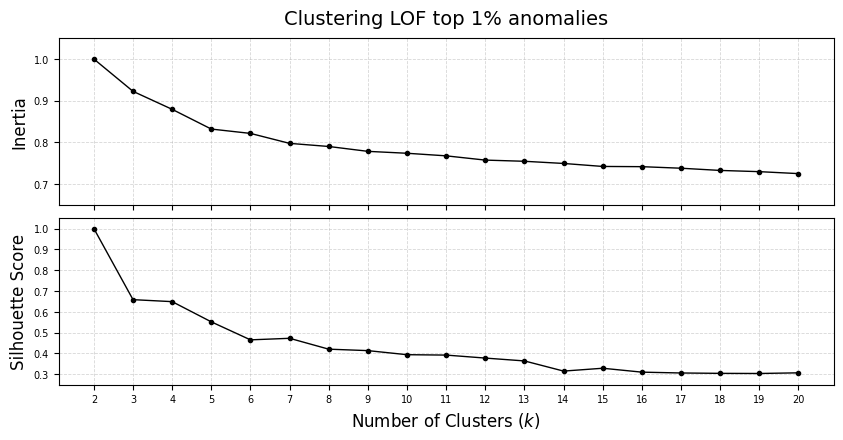

## Train data

In [12]:
X = weights_dict["norm_unique_norm_weights"]

## Train and save

In [13]:
# ```python
start_time = time.perf_counter()

kmeans_model = KMeans(n_clusters=n_clusters, random_state=0).fit(X)

end_time = time.perf_counter()
print(f"train time: {end_time - start_time:.2f} seconds")

# save model
joblib.dump(kmeans_model, f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
# ```

# ```python
# train time: 0.17 seconds
# ['/home/elom/phd/code/clustering/bin_03/lof/kmeans_5_clusters_343_segments.joblib']
# ```

train time: 0.18 seconds


['/home/elom/phd/code/clustering/bin_03/lof/kmeans_5_clusters_343_segments.joblib']

## Save metadata

In [14]:
# ```python
kmeans_model = joblib.load(f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
cluster_labels = kmeans_model.predict(X)

cluster_meta_df = meta_with_ratios_df.loc[specobjids_arr].copy()
cluster_meta_df["cluster"] = cluster_labels

# append score, specobjids_arr is already sorted by score
cluster_meta_df[score_name] = scores_df[score_name].loc[specobjids_arr].copy()
cluster_meta_df.to_csv(f"{kmeans_model_dir}/metadata.csv.gz", compression="gzip")

# Clusters metadata

In [15]:
kmeans_model = joblib.load(f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
cluster_labels = kmeans_model.predict(X)

# get spectra and weights per cluster
spectra_cluster_dict, weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=weights_dict["norm_weights"],
    print_n_clusters=True,
)

weights_dict["spectra_cluster_dict"] = spectra_cluster_dict
weights_dict["weights_cluster_dict"] = weights_cluster_dict


weights_dict["centroids"] = kmeans_model.cluster_centers_

# 0;179
# 1;735
# 2;239
# 3;153
# 4;513


0;179
1;735
2;239
3;153
4;513


In [16]:
cluster_meta_df = pd.read_csv(
    f"{kmeans_model_dir}/metadata.csv.gz", index_col="specobjid"
).loc[specobjids_arr]

# Line ratios

## Median line ratios

In [23]:
median_cluster_ratios_df = pd.DataFrame(
    index=range(0, n_clusters),
    columns=SDSS_NEBULAR_LINES_RATIOS_NAMES,
)
for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id

    median_cluster_ratios_df.loc[cluster_id, "balmer_decrement"] = np.nanmedian(
        cluster_meta_df.loc[mask, "balmer_decrement"]
    )
    median_cluster_ratios_df.loc[cluster_id, "nii_to_halpha"] = np.nanmedian(
        cluster_meta_df.loc[mask, "nii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_hbeta"] = np.nanmedian(
        cluster_meta_df.loc[mask, "oiii_to_hbeta"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_oii"] = np.nanmedian(
        cluster_meta_df.loc[mask, "oiii_to_oii"]
    )
    median_cluster_ratios_df.loc[cluster_id, "o3n2_index"] = np.nanmedian(
        cluster_meta_df.loc[mask, "o3n2_index"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_to_halpha"] = np.nanmedian(
        cluster_meta_df.loc[mask, "sii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_density_ratio"] = np.nanmedian(
        cluster_meta_df.loc[mask, "sii_density_ratio"]
    )
# map col name by replacing the '_' with ' ' for better readability
median_cluster_ratios_df.columns = [
    col.replace("_", " ") for col in median_cluster_ratios_df.columns
]

median_cluster_ratios_df.to_clipboard(excel=True, index=True)
median_cluster_ratios_df

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
0,3.777621,0.258097,1.40243,1.023324,0.296658,1.340184,0.71343
1,3.556258,0.582294,0.912197,0.928274,0.357369,1.329513,0.157178
2,4.199655,0.344494,0.894205,1.04186,0.27232,1.312722,0.366084
3,3.644907,0.248912,2.537189,2.149164,0.239575,1.321914,0.891787
4,3.340514,0.745891,1.397521,1.121283,0.505395,1.456495,0.241793


## Cluster 0 ratios percentiles

In [18]:
cluster_mask = cluster_meta_df["cluster"] == 0
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df.T.to_clipboard(excel=True, index=True)
ratios_percentiles_df.T

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
45th,3.720639,0.248957,1.360764,0.928179,0.289180,1.332722,0.688699
50th,3.777621,0.258097,1.402430,1.023324,0.296658,1.340184,0.713430
55th,3.838421,0.277448,1.463931,1.105892,0.306738,1.353552,0.788166


## Cluster 1 ratios percentiles

In [19]:
cluster_mask = cluster_meta_df["cluster"] == 1
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df.T.to_clipboard(excel=True, index=True)
ratios_percentiles_df.T

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
45th,3.197248,0.525454,0.787341,0.804501,0.336519,1.295543,0.097293
50th,3.556258,0.582294,0.912197,0.928274,0.357369,1.329513,0.157178
55th,3.784225,0.622542,1.048642,1.008194,0.382767,1.365503,0.240910


## Cluster 2 percentiles

In [20]:
cluster_mask = cluster_meta_df["cluster"] == 2
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df.T.to_clipboard(excel=True, index=True)
ratios_percentiles_df.T

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
45th,4.107083,0.329880,0.753847,0.914853,0.264548,1.295930,0.303404
50th,4.199655,0.344494,0.894205,1.041860,0.272320,1.312722,0.366084
55th,4.311388,0.361289,0.982641,1.136215,0.279509,1.325528,0.459635


## Cluster 3 ratios percentiles

In [21]:
cluster_mask = cluster_meta_df["cluster"] == 3
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df.T.to_clipboard(excel=True, index=True)
ratios_percentiles_df.T

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
45th,3.604527,0.231673,2.311648,1.963327,0.225326,1.298131,0.827389
50th,3.644907,0.248912,2.537189,2.149164,0.239575,1.321914,0.891787
55th,3.721261,0.274423,2.974332,2.275392,0.257146,1.333760,0.983569


## Cluster 4 ratios percentiles

In [22]:
cluster_mask = cluster_meta_df["cluster"] == 4
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df.T.to_clipboard(excel=True, index=True)
ratios_percentiles_df.T

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
45th,3.177552,0.693209,1.264821,0.992534,0.474909,1.405348,0.216135
50th,3.340514,0.745891,1.397521,1.121283,0.505395,1.456495,0.241793
55th,3.664130,0.813112,1.607010,1.252513,0.556066,1.537671,0.285860


# Redshift Analysis

In [24]:
z_dict = {"cluster": [], "z_min": [], "z_max": [], "z_mean": [], "z_median": []}

for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id
    z = cluster_meta_df["z"].loc[mask].values

    z_dict["cluster"].append(cluster_id)
    z_dict["z_min"].append(np.min(z))
    z_dict["z_max"].append(np.max(z))
    z_dict["z_mean"].append(np.mean(z))
    z_dict["z_median"].append(np.median(z))
z_df = pd.DataFrame(z_dict)
z_df

,cluster,z_min,z_max,z_mean,z_median
0,0,0.022368,0.215538,0.076910,0.071867
1,1,0.011012,0.290295,0.081899,0.077307
2,2,0.010398,0.263567,0.057608,0.040940
3,3,0.010551,0.240697,0.059394,0.037146
4,4,0.010200,0.219666,0.088013,0.083364


In [25]:
low_wave, upper_wave = 5_565, 5_590
z_df["lower_wave_min"] = low_wave / (1 + z_df["z_min"])
z_df["upper_wave_min"] = upper_wave / (1 + z_df["z_min"])
z_df["lower_wave_max"] = low_wave / (1 + z_df["z_max"])
z_df["upper_wave_max"] = upper_wave / (1 + z_df["z_max"])
z_df["lower_wave_mean"] = low_wave / (1 + z_df["z_mean"])
z_df["upper_wave_mean"] = upper_wave / (1 + z_df["z_mean"])
z_df["lower_wave_median"] = low_wave / (1 + z_df["z_median"])
z_df["upper_wave_median"] = upper_wave / (1 + z_df["z_median"])
z_df

,cluster,z_min,z_max,z_mean,z_median,lower_wave_min,upper_wave_min,lower_wave_max,upper_wave_max,lower_wave_mean,upper_wave_mean,lower_wave_median,upper_wave_median
0,0,0.022368,0.215538,0.076910,0.071867,5443.247348,5467.700391,4578.218556,4598.785575,5167.564264,5190.778839,5191.876308,5215.200101
1,1,0.011012,0.290295,0.081899,0.077307,5504.384997,5529.112692,4312.968861,4332.344283,5143.731785,5166.839296,5165.659210,5188.865226
2,2,0.010398,0.263567,0.057608,0.040940,5507.730999,5532.473725,4404.197893,4423.983149,5261.872230,5285.510470,5346.128279,5370.145027
3,3,0.010551,0.240697,0.059394,0.037146,5506.897713,5531.636697,4485.383815,4505.533787,5253.004520,5276.602923,5365.684875,5389.789479
4,4,0.010200,0.219666,0.088013,0.083364,5508.809155,5533.556725,4562.726046,4583.223467,5114.830373,5137.808047,5136.776766,5159.853032


# Clusters' XAI

## Centroid & Avg Spec

In [26]:
lw = 0.75
for label, centroid in enumerate(weights_dict["centroids"]):

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 7),
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    centroid = clustering.expand_weights_per_segments(
        centroid.reshape(1, -1),
        wave_nm.size,
        n_segments,
    )
    centroid = clustering.normalize_weights_l2_abs(centroid).reshape(-1)
    avg_spectrum = weights_dict["spectra_cluster_dict"][label].mean(axis=0)

    axs[0].plot(
        wave_nm, avg_spectrum, color="black", label="Average spectrum", linewidth=lw
    )
    axs[0].legend()
    # weights
    axs[1].plot(
        wave_nm, centroid, color="black", label="Centroid explanation", linewidth=lw
    )
    axs[1].legend()
    # set limits
    # set limits
    axs[1].set_ylim(0, 0.31)
    y_ticks = np.arange(0, 0.31, 0.1)
    axs[1].set_yticks(y_ticks)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label}",
        fontsize=12,
    )

    plot_name = f"avg_spec_centroid_{label}"

    save_to = f"{kmeans_model_dir}/avg_spec_centroids"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

## Centroid & Median Spec

In [27]:
lw = 0.75
for label, centroid in enumerate(weights_dict["centroids"]):

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 7),
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    centroid = clustering.expand_weights_per_segments(
        centroid.reshape(1, -1),
        wave_nm.size,
        n_segments,
    )
    centroid = clustering.normalize_weights_l2_abs(centroid).reshape(-1)
    _spec = weights_dict["spectra_cluster_dict"][label]
    med_spec = np.nanmedian(_spec, axis=0)

    axs[0].plot(
        wave_nm, med_spec, color="black", label="Median spectrum", linewidth=lw
    )
    axs[0].legend()
    # weights
    axs[1].plot(
        wave_nm, centroid, color="black", label="Centroid explanation", linewidth=lw
    )
    axs[1].legend()
    # set limits
    # set limits
    axs[1].set_ylim(0, 0.31)
    y_ticks = np.arange(0, 0.31, 0.1)
    axs[1].set_yticks(y_ticks)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label}",
        fontsize=12,
    )

    plot_name = f"median_spec_centroid_{label}"

    save_to = f"{kmeans_model_dir}/median_spec_centroids"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

## Avg Spec & XAI

In [28]:
lw = 0.75
for label_cluster, weights in weights_dict['weights_cluster_dict'].items():

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 7),
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    spec = weights_dict["spectra_cluster_dict"][label_cluster]

    avg_spectrum = spec.mean(axis=0)
    avg_weights = weights.mean(axis=0)

    axs[0].plot(
        wave_nm, avg_spectrum, color="black", label="Average spectrum", linewidth=lw
    )
    axs[0].legend()
    # weights
    axs[1].plot(
        wave_nm, avg_weights, color="black", label="Average explanation", linewidth=lw
    )
    axs[1].legend()
    # set limits
    axs[1].set_ylim(0, 0.31)
    y_ticks = np.arange(0, 0.31, 0.1)
    axs[1].set_yticks(y_ticks)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label_cluster}",
        fontsize=12,
    )

    plot_name = f"avg_spec_xai_{label_cluster}"

    save_to = f"{kmeans_model_dir}/avg_spec_xai"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

## Median Spec & XAI

In [29]:
lw = 0.75
for label_cluster, weights in weights_dict['weights_cluster_dict'].items():

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 7),
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    spec = weights_dict["spectra_cluster_dict"][label_cluster]

    median_spec = np.nanmedian(spec, axis=0)
    median_weights = np.nanmedian(weights, axis=0)

    axs[0].plot(
        wave_nm, median_spec, color="black", label="Median spectrum", linewidth=lw
    )
    axs[0].legend()
    # weights
    axs[1].plot(
        wave_nm, median_weights, color="black", label="Median explanation", linewidth=lw
    )
    axs[1].legend()
    # set limits
    axs[1].set_ylim(0, 0.31)
    y_ticks = np.arange(0, 0.31, 0.1)
    axs[1].set_yticks(y_ticks)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label_cluster}",
        fontsize=12,
    )

    plot_name = f"median_spec_xai_{label_cluster}"

    save_to = f"{kmeans_model_dir}/median_spec_xai"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

# Top ranked anomalies per cluster

In [30]:
# cluster_id = 4

# mask = cluster_meta_df["cluster"] == cluster_id

# metadata_df = cluster_meta_df.loc[mask].sort_values(
#     by=f"{score_name}", ascending=False
# )

# spectra = anomalies_arr[mask]
# norm_weights = weights_dict["norm_weights"][mask]

# plot_top_ranked_explanations(
#     cluster_id=cluster_id,
#     metadata_df=metadata_df,
#     spectra=spectra,
#     norm_weights=norm_weights,
#     wave=wave_nm,
#     kmeans_model_dir=kmeans_model_dir,
#     download_images=True,
#     n_top_ranked=-1,
#     max_norm_weights=False,
#     # skip_ranks_list=[57]
# )

## Check ranking

In [31]:
cluster_id = 0
mask = cluster_meta_df["cluster"] == cluster_id
metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)

spectra = anomalies_arr[mask]
norm_weights = weights_dict["norm_weights"][mask]
metadata_df.loc[:, ["cluster", score_name]].head(10)
# scores_df.loc[mask].head(10)

,cluster,lof
specobjid,,
2245159102839810048,0,0.932709
1071977423131666432,0,0.893479
1919783100783552512,0,0.858510
880459813388052480,0,0.713571
2490533538458265600,0,0.708715
507921902363240448,0,0.673012
1041590495186282496,0,0.627563
1533533173772740608,0,0.613291
2504067977276581888,0,0.595758


In [32]:
anomaly_rank = 4
cluster_id = 0

mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)

n_anomalies_in_cluster = metadata_df.shape[0]
print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

specobjid = metadata_df.index[anomaly_rank]
metadata_df.loc[specobjid, ["cluster", score_name]]

Number of anomalies in cluster 0: 179


cluster           0
lof        0.708715
Name: 2490533538458265600, dtype: object

# Cluster 1 and 4

## Data prep

In [34]:
# Cluster 1
weights_1 = weights_dict["weights_cluster_dict"][1]
med_weights_1 = np.nanmedian(weights_1, axis=0)
spec_1 = weights_dict["spectra_cluster_dict"][1]
med_spec_1 = np.nanmedian(spec_1, axis=0)

# Cluster 4
weights_4 = weights_dict["weights_cluster_dict"][4]
med_weights_4 = np.nanmedian(weights_4, axis=0)
spec_4 = weights_dict["spectra_cluster_dict"][4]
med_spec_4 = np.nanmedian(spec_4, axis=0)

## Figure

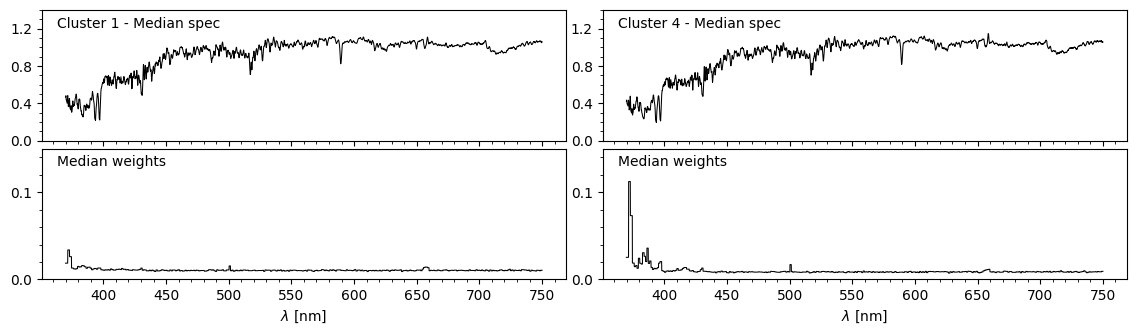

In [53]:
lw = 0.75

fig, axs = plt.subplots(
    nrows=2, ncols=2,
    figsize=(14, 3.5),
    sharex=True,
    sharey=False,
)

# ------------------------------------------------------------------
# Cluster 1
axs[0, 0].plot(wave_nm, med_spec_1, color="black", linewidth=lw)

y_lims = (0, 1.4)
y_ticks = [0, 0.4, 0.8, 1.2]
axs[0, 0].set_ylim(y_lims)
axs[0, 0].set_yticks(y_ticks)

# weights
axs[1, 0].plot(wave_nm, med_weights_1, color="black", linewidth=lw)

# ------------------------------------------------------------------
# Cluster 4
axs[0, 1].plot(wave_nm, med_spec_4, color="black", linewidth=lw)

y_lims = (0, 1.4)
y_ticks = [0, 0.4, 0.8, 1.2]
axs[0, 1].set_ylim(y_lims)
axs[0, 1].set_yticks(y_ticks)

# weights
axs[1, 1].plot(wave_nm, med_weights_4, color="black", linewidth=lw)

# --------------------------------------------------------------------
# lim and ticks for explanation weights
y_lims = (0, 0.15)
y_ticks = np.arange(0, 0.15, 0.1)

axs[1, 0].set_ylim(y_lims)
axs[1, 0].set_yticks(y_ticks)
axs[1, 1].set_ylim(y_lims)
axs[1, 1].set_yticks(y_ticks)

# wavelength
axs[-1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[-1, 1].set_xlabel(r"$\lambda$ [nm]")

# set minor ticks on
for ax in axs.flatten():
    ax.minorticks_on()

# add text
i = 0
axs[i , 0].text(
    0.03, 0.95, f'Cluster {i + 1} - Median spec',
    transform=axs[i, 0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)
axs[i + 1, 0].text(
    # 0.03, 0.95, f'Cluster {i + 1} - Med weights',
    0.03, 0.95, 'Median weights',
    transform=axs[i + 1, 0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

axs[i, 1].text(
    0.03, 0.95, f'Cluster {i + 4} - Median spec',
    transform=axs[i, 1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)
axs[i + 1, 1].text(
    # 0.03, 0.95, f'Cluster {i + 4} - Median weights',
    0.03, 0.95, 'Median weights',
    transform=axs[i + 1, 1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

plt.subplots_adjust(hspace=0.06, wspace=0.07)
plt.show()
# save fig
fname = 'lof_clusters_1_4'
fig.savefig(f"{ch_6_dir}/{fname}_med.pdf", bbox_inches="tight")

# Cluster 0 and 3

## Data prep

In [38]:
# Cluster 0
weights_0 = weights_dict["weights_cluster_dict"][0]
med_weights_0 = np.nanmedian(weights_0, axis=0)
spec_0 = weights_dict["spectra_cluster_dict"][0]
med_spec_0 = np.nanmedian(spec_0, axis=0)

# Cluster 3
weights_3 = weights_dict["weights_cluster_dict"][3]
med_weights_3 = np.nanmedian(weights_3, axis=0)
spec_3 = weights_dict["spectra_cluster_dict"][3]
med_spec_3 = np.nanmedian(spec_3, axis=0)

## Figure

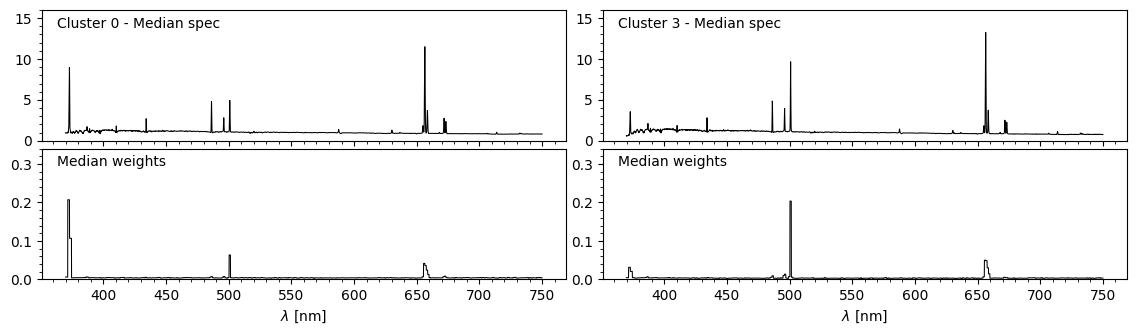

In [50]:
lw = 0.75

fig, axs = plt.subplots(
    nrows=2, ncols=2,
    figsize=(14, 3.5),
    sharex=True,
    sharey=False,
)

# ------------------------------------------------------------------
# Cluster 0
axs[0, 0].plot(wave_nm, med_spec_0, color="black", linewidth=lw)

y_lims = (0, 16)
y_ticks = range(0, 16, 5)
axs[0, 0].set_ylim(y_lims)
axs[0, 0].set_yticks(y_ticks)

# weights
axs[1, 0].plot(wave_nm, med_weights_0, color="black", linewidth=lw)

# ------------------------------------------------------------------
# Cluster 3
axs[0, 1].plot(wave_nm, med_spec_3, color="black", linewidth=lw)

y_lims = (0, 16)
y_ticks = range(0, 16, 5)
axs[0, 1].set_ylim(y_lims)
axs[0, 1].set_yticks(y_ticks)

# weights
axs[1, 1].plot(wave_nm, med_weights_3, color="black", linewidth=lw)

# --------------------------------------------------------------------
# lim and ticks for explanation weights
y_lims = (0, 0.34)
y_ticks = np.arange(0, 0.34, 0.1)

axs[1, 0].set_ylim(y_lims)
axs[1, 0].set_yticks(y_ticks)
axs[1, 1].set_ylim(y_lims)
axs[1, 1].set_yticks(y_ticks)

# wavelength
axs[-1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[-1, 1].set_xlabel(r"$\lambda$ [nm]")

# set minor ticks on
for ax in axs.flatten():
    ax.minorticks_on()

# add text
i = 0
axs[i , 0].text(
    0.03, 0.95, f'Cluster {i} - Median spec',
    transform=axs[i, 0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)
axs[i + 1, 0].text(
    # 0.03, 0.95, f'Cluster {i} - Med weights',
    0.03, 0.95, 'Median weights',
    transform=axs[i + 1, 0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

axs[i, 1].text(
    0.03, 0.95, f'Cluster {i + 3} - Median spec',
    transform=axs[i, 1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)
axs[i + 1, 1].text(
    # 0.03, 0.95, f'Cluster {i + 3} - Median weights',
    0.03, 0.95, 'Median weights',
    transform=axs[i + 1, 1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

plt.subplots_adjust(hspace=0.06, wspace=0.07)
plt.show()
# save fig
fname = 'lof_clusters_0_3'
fig.savefig(f"{ch_6_dir}/{fname}_med.pdf", bbox_inches="tight")

# Cluster 2

## Data prep

In [40]:
# Cluster 2
weights_2 = weights_dict["weights_cluster_dict"][2]
med_weights_2 = np.nanmedian(weights_2, axis=0)
spec_2 = weights_dict["spectra_cluster_dict"][2]
med_spec_2 = np.nanmedian(spec_2, axis=0)


## Figure

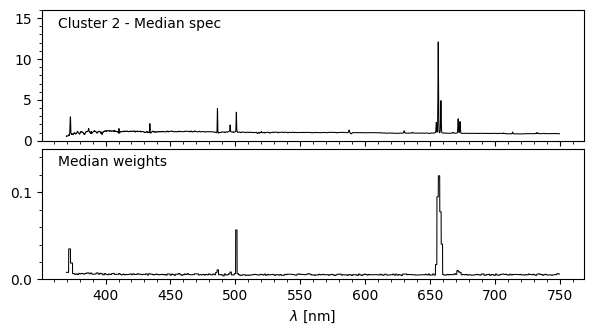

In [55]:
lw = 0.75

fig, axs = plt.subplots(
    nrows=2, ncols=1,
    figsize=(7, 3.5),
    sharex=True,
    sharey=False,
)

# ------------------------------------------------------------------
# Cluster 2
axs[0].plot(wave_nm, med_spec_2, color="black", linewidth=lw)

y_lims = (0, 16)
y_ticks = range(0, 16, 5)
axs[0].set_ylim(y_lims)
axs[0].set_yticks(y_ticks)

# weights
axs[1].plot(wave_nm, med_weights_2, color="black", linewidth=lw)

# --------------------------------------------------------------------
# lim and ticks for explanation weights
y_lims = (0, 0.15)
y_ticks = np.arange(0, 0.15, 0.1)

axs[1].set_ylim(y_lims)
axs[1].set_yticks(y_ticks)

# wavelength
axs[-1].set_xlabel(r"$\lambda$ [nm]")

# set minor ticks on
for ax in axs.flatten():
    ax.minorticks_on()

# add text
i = 0
axs[0].text(
    0.03, 0.95, f'Cluster 2 - Median spec',
    transform=axs[0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)
axs[1].text(
    # 0.03, 0.95, f'Cluster 2 - Med weights',
    0.03, 0.95, 'Median weights',
    transform=axs[1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)


plt.subplots_adjust(hspace=0.06, wspace=0.07)
plt.show()
# save fig
fname = 'lof_clusters_2'
fig.savefig(f"{ch_6_dir}/{fname}_med.pdf", bbox_inches="tight")

# BPT

['(0)', '(1)', '(2)', '(3)', '(4)']
[-0.58821695 -0.23485778 -0.4628189  -0.60395443 -0.12732461]
[ 0.14688129 -0.03991133 -0.04856273  0.40435287  0.14535836]


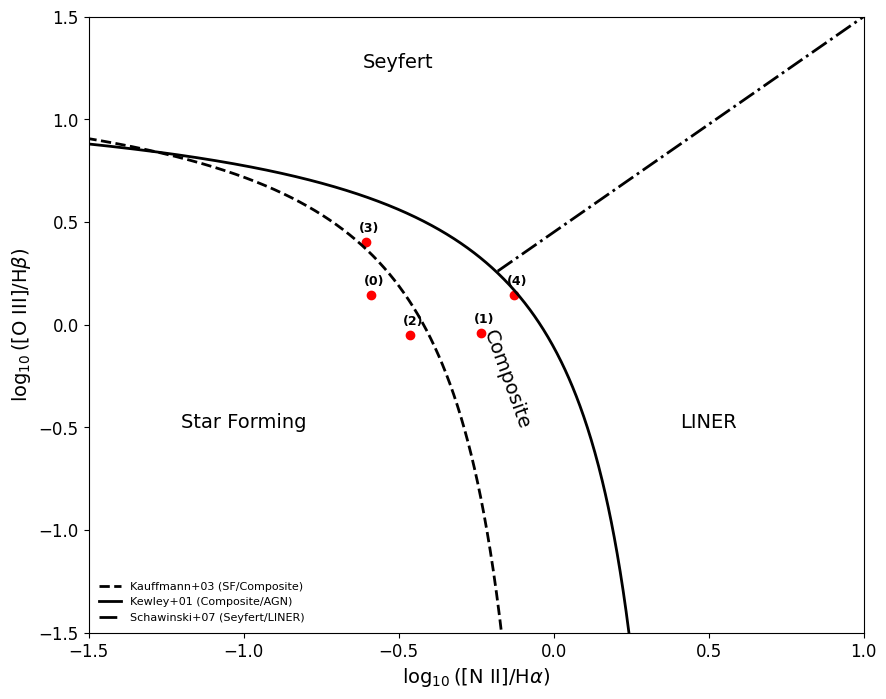

In [43]:
labels = [f"({i})" for i in range(0, n_clusters)]
print(labels)

n2_ha = median_cluster_ratios_df["nii to halpha"].to_list()
o3_hb = median_cluster_ratios_df["oiii to hbeta"].to_list()
log_n2_ha = np.log10(n2_ha)
log_o3_hb = np.log10(o3_hb)

print(log_n2_ha)
print(log_o3_hb)

fig, ax = plt.subplots(figsize=(10, 8))
fig, ax = BPT.standar_bpt_plot(fig, ax, log_n2_ha, log_o3_hb, labels, xytext=(-5, 5))

# SDSS class

In [44]:
cluster_id = 0
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
# metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)/mask.sum()*100

subClass
STARBURST                70.391061
STARFORMING              14.525140
NaN                       5.027933
AGN BROADLINE             3.351955
AGN                       2.793296
STARFORMING BROADLINE     2.234637
STARBURST BROADLINE       1.675978
Name: count, dtype: float64

In [45]:
cluster_id = 1
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
# metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)/mask.sum()*100

subClass
NaN                      71.156463
STARFORMING              15.102041
STARBURST                 5.170068
AGN                       4.081633
BROADLINE                 2.176871
AGN BROADLINE             2.040816
STARFORMING BROADLINE     0.272109
Name: count, dtype: float64

In [46]:
cluster_id = 2
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
# metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)/mask.sum()*100

subClass
STARBURST                70.292887
STARFORMING              13.807531
AGN                       8.786611
AGN BROADLINE             4.184100
STARBURST BROADLINE       1.255230
BROADLINE                 0.836820
NaN                       0.418410
STARFORMING BROADLINE     0.418410
Name: count, dtype: float64

In [47]:
cluster_id = 3
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
# metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)/mask.sum()*100

subClass
STARBURST        68.627451
AGN              18.954248
STARFORMING       9.150327
NaN               1.307190
AGN BROADLINE     1.307190
BROADLINE         0.653595
Name: count, dtype: float64

In [48]:
cluster_id = 4
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
# metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)/mask.sum()*100

subClass
NaN                      83.430799
STARFORMING               8.187135
BROADLINE                 3.898635
AGN                       1.754386
STARBURST                 1.559454
STARFORMING BROADLINE     0.584795
AGN BROADLINE             0.584795
Name: count, dtype: float64